In [1]:
# cargo un dataframe en df_epic_ligh.pickle
import pandas as pd
df = pd.read_pickle('df_fe_epic_light.pickle')
df

,product_id,fecha,customer_id,plan_precios_cuidados,cust_request_qty,cust_request_tn,tn,stock_final,cat1,cat2,...,tn_sku_size_vendidas_div,tn_product_id_vendidas,tn_product_id_vendidas_div,tn_customer_id_vendidas,tn_customer_id_vendidas_div,tn_customer_vendidas,tn_total_vendidas,customer_weight,tn_product_vendidas,product_weight
377076,20022,2017-01,10001,0.0,10,15.357890,15.357890,NaN,HC,ROPA LAVADO,...,0.045110,316.557709,0.048515,192.097549,0.079948,192.097549,2199.395996,0.087341,316.557709,0.143929
377112,20022,2017-01,10002,0.0,11,42.002689,42.002689,NaN,HC,ROPA LAVADO,...,0.123371,316.557709,0.132686,201.882339,0.208055,201.882339,2199.395996,0.091790,316.557709,0.143929
377148,20022,2017-01,10003,0.0,19,7.408130,7.408130,NaN,HC,ROPA LAVADO,...,0.021759,316.557709,0.023402,144.609573,0.051228,144.609573,2199.395996,0.065750,316.557709,0.143929
377184,20022,2017-01,10004,0.0,13,3.581760,3.581760,NaN,HC,ROPA LAVADO,...,0.010520,316.557709,0.011315,114.982391,0.031151,114.982391,2199.395996,0.052279,316.557709,0.143929
377220,20022,2017-01,10005,0.0,6,9.225220,9.225220,NaN,HC,ROPA LAVADO,...,0.027097,316.557709,0.029142,76.058220,0.121292,76.058220,2199.395996,0.034581,316.557709,0.143929
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15758095,21276,2019-12,10591,0.0,0,0.000000,0.000000,1.05592,PC,PIEL1,...,0.000000,0.008920,0.000000,0.000000,NaN,0.000000,1289.313599,0.000000,0.008920,0.000007
15758105,21276,2019-12,10597,0.0,0,0.000000,0.000000,1.05592,PC,PIEL1,...,0.000000,0.008920,0.000000,0.000000,NaN,0.000000,1289.313599,0.000000,0.008920,0.000007
15758108,21276,2019-12,10599,0.0,0,0.000000,0.000000,1.05592,PC,PIEL1,...,0.000000,0.008920,0.000000,0.000000,NaN,0.000000,1289.313599,0.000000,0.008920,0.000007
15758117,21276,2019-12,10606,0.0,0,0.000000,0.000000,1.05592,PC,PIEL1,...,0.000000,0.008920,0.000000,0.012980,0.000000,0.012980,1289.313599,0.000010,0.008920,0.000007


In [2]:
test_index = df.index[df['date_id'] == 33]
train_index = df.index[df['date_id'] <= 31]
train_scaler_index = df.index[df['date_id'] <= 33]

In [3]:
numeric_columns = df.select_dtypes(include=['float64', "float32"]).columns
numeric_columns

Index(['plan_precios_cuidados', 'cust_request_tn', 'tn', 'stock_final',
       'sku_size', 'coseno_fecha', 'seno_fecha', 'cust_request_tn_minus_tn',
       'tn_mult_cust_request_qty', 'tn_diff_1', 'tn_diff_2', 'tn_diff_3',
       'tn_diff_5', 'tn_diff_11', 'cust_request_qty_diff_1',
       'cust_request_qty_diff_2', 'cust_request_qty_diff_3',
       'cust_request_qty_diff_5', 'cust_request_qty_diff_11', 'tn_lag_1',
       'tn_lag_2', 'tn_lag_3', 'tn_lag_5', 'tn_lag_11',
       'cust_request_qty_lag_1', 'cust_request_qty_lag_2',
       'cust_request_qty_lag_3', 'cust_request_qty_lag_5',
       'cust_request_qty_lag_11', 'tn_rolling_mean_3', 'tn_rolling_mean_12',
       'cust_request_qty_rolling_mean_3', 'cust_request_qty_rolling_mean_12',
       'tn_rolling_std_3', 'tn_rolling_std_12',
       'cust_request_qty_rolling_std_3', 'cust_request_qty_rolling_std_12',
       'tn_rolling_max_3', 'tn_rolling_max_12',
       'cust_request_qty_rolling_max_3', 'cust_request_qty_rolling_max_12',
    

In [4]:
# diccionario de transformaciones (key es la columna con la que se entrena y el valor son las columnas que se transforman)
transformations = {
    "tn": [r"tn$", r"cust_request_qty_per_tn$", r"tn_lag_*", r"tn_rolling_mean_*", r"tn_rolling_max_*", r"tn_rolling_min_*", r"tn_.*_vendidas$"],
    "stock_final": [r"stock_final$"],
    "cust_request_tn_minus_tn": [r"cust_request_tn_minus_tn$"],
    "tn_diff_2": [r"tn_diff_*"]
}

In [5]:
import numpy as np
import re

df_scaled = df.copy()
train_scaler_df = df_scaled.loc[train_scaler_index]

prod_stats = (
    train_scaler_df.groupby('product_id')[list(transformations.keys())]
    .agg(['mean', 'std'])
)

def custom_group_stats(group):
    product_id = group.name[1]
    row = {'customer_id': group.name[0], 'product_id': product_id}
    for col in transformations.keys():
        nonzero_count = (group[col] != 0).sum()
        if nonzero_count <= 3:
            mean = prod_stats.loc[product_id, (col, 'mean')]
            std = prod_stats.loc[product_id, (col, 'std')]
        else:
            mean = group[col].mean()
            std = group[col].std()
            if std < 1:
                std = max(group[col].max(), 1)
        row[f"{col}_mean"] = mean
        row[f"{col}_std"] = std
    return pd.Series(row)

group_stats = train_scaler_df.groupby(['customer_id', 'product_id']).apply(custom_group_stats).reset_index(drop=True)

group_stats

/tmp/ipykernel_189408/1928279191.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  group_stats = train_scaler_df.groupby(['customer_id', 'product_id']).apply(custom_group_stats).reset_index(drop=True)


,customer_id,product_id,tn_mean,tn_std,stock_final_mean,stock_final_std,cust_request_tn_minus_tn_mean,cust_request_tn_minus_tn_std,tn_diff_2_mean,tn_diff_2_std
0,10001.0,20022.0,10.973444,10.291185,125.278267,161.339752,0.011220,0.207875,-0.553098,14.996762
1,10001.0,20030.0,29.630669,27.240080,75.364799,64.324509,0.280494,3.494400,-2.056600,23.853441
2,10001.0,20064.0,9.512711,7.664634,50.129799,49.453308,0.005307,0.144454,-0.293475,10.537648
3,10001.0,20070.0,8.392891,3.694780,40.414326,30.703568,0.002837,0.093667,-0.128874,4.224156
4,10001.0,20074.0,10.201523,8.649384,37.196720,44.074093,0.007055,0.211943,0.051080,11.956935
...,...,...,...,...,...,...,...,...,...,...
56621,10637.0,21125.0,0.001020,0.006879,1.960102,2.330905,0.000000,0.000000,-0.000100,0.007126
56622,10637.0,21192.0,0.000399,0.008424,1.818977,0.297984,0.000000,0.000000,-0.000139,0.009599
56623,10637.0,21208.0,0.001312,0.007720,NaN,NaN,0.000000,0.000000,-0.000133,0.009545
56624,10637.0,21215.0,0.000974,0.012141,NaN,NaN,0.000008,0.000538,-0.000585,0.016133


In [7]:

# Mergear las stats al df original
df_scaled = df_scaled.merge(group_stats, on=['product_id', "customer_id"], how='left')
df_scaled = df_scaled.set_index(df.index)

scaled_cols = {}
for trainer, regex_cols in transformations.items():
    for col in regex_cols:
        # Usar regex para seleccionar las columnas que coinciden
        # chequear si la columna es un regex
        matching_cols = [c for c in numeric_columns if re.match(col, c)]
        if not matching_cols:
            continue  # Si no hay columnas que coincidan, saltar

        # Calcular la media y desviación estándar para cada 
        print(f"Processing trainer: {trainer} with columns: {matching_cols}")
        for match_col in matching_cols:
            mean_col = f"{trainer}_mean"
            std_col = f"{trainer}_std"

        # Escalar las columnas
        for col in matching_cols:
            #scaled_cols[col + "_scaled"] = (df_scaled[col] - df_scaled[trainer + "_mean"]) / df_scaled[trainer + "_std"]
            scaled_cols[col + "_scaled"] = (df_scaled[col]) / df_scaled[trainer + "_std"]
            # reemplazo nan por 0 e inf por 0
            #scaled_cols[col + "_scaled"] = scaled_cols[col + "_scaled"].replace([np.inf, -np.inf], 0)

# Crear un DataFrame con todas las columnas escaladas
scaled_df = pd.DataFrame(scaled_cols, index=df_scaled.index)

# Concatenar de una sola vez
df_scaled = pd.concat([df_scaled, scaled_df], axis=1)
aux_cols = [col + "_mean" for col in list(transformations.keys())] + [col + "_std" for col in list(transformations.keys())]
df_scaled = df_scaled.drop(columns=aux_cols)

df_scaled

Processing trainer: tn with columns: ['tn']
Processing trainer: tn with columns: ['tn_lag_1', 'tn_lag_2', 'tn_lag_3', 'tn_lag_5', 'tn_lag_11']
Processing trainer: tn with columns: ['tn_rolling_mean_3', 'tn_rolling_mean_12']
Processing trainer: tn with columns: ['tn_rolling_max_3', 'tn_rolling_max_12']
Processing trainer: tn with columns: ['tn_rolling_min_3', 'tn_rolling_min_12']
Processing trainer: tn with columns: ['tn_cat1_vendidas', 'tn_cat2_vendidas', 'tn_cat3_vendidas', 'tn_brand_vendidas', 'tn_sku_size_vendidas', 'tn_product_id_vendidas', 'tn_customer_id_vendidas', 'tn_customer_vendidas', 'tn_total_vendidas', 'tn_product_vendidas']
Processing trainer: stock_final with columns: ['stock_final']
Processing trainer: cust_request_tn_minus_tn with columns: ['cust_request_tn_minus_tn']
Processing trainer: tn_diff_2 with columns: ['tn_diff_1', 'tn_diff_2', 'tn_diff_3', 'tn_diff_5', 'tn_diff_11']


KeyboardInterrupt: 

In [9]:
df_scaled

,product_id,fecha,customer_id,plan_precios_cuidados,cust_request_qty,cust_request_tn,tn,stock_final,cat1,cat2,...,tn_customer_vendidas_scaled,tn_total_vendidas_scaled,tn_product_vendidas_scaled,stock_final_scaled,cust_request_tn_minus_tn_scaled,tn_diff_1_scaled,tn_diff_2_scaled,tn_diff_3_scaled,tn_diff_5_scaled,tn_diff_11_scaled
377076,20022,2017-01,10001,0.0,10,15.357890,15.357890,NaN,HC,ROPA LAVADO,...,18.666222,213.716488,30.760082,NaN,0.0,NaN,NaN,NaN,NaN,NaN
377112,20022,2017-01,10002,0.0,11,42.002689,42.002689,NaN,HC,ROPA LAVADO,...,8.395918,91.468861,13.165057,NaN,0.0,NaN,NaN,NaN,NaN,NaN
377148,20022,2017-01,10003,0.0,19,7.408130,7.408130,NaN,HC,ROPA LAVADO,...,43.838693,666.751478,95.965129,NaN,0.0,NaN,NaN,NaN,NaN,NaN
377184,20022,2017-01,10004,0.0,13,3.581760,3.581760,NaN,HC,ROPA LAVADO,...,112.988586,2161.258272,311.068570,NaN,0.0,NaN,NaN,NaN,NaN,NaN
377220,20022,2017-01,10005,0.0,6,9.225220,9.225220,NaN,HC,ROPA LAVADO,...,2.787456,80.605610,11.601516,NaN,0.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15758095,21276,2019-12,10591,0.0,0,0.000000,0.000000,1.05592,PC,PIEL1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15758105,21276,2019-12,10597,0.0,0,0.000000,0.000000,1.05592,PC,PIEL1,...,0.000000,693469.564612,4.797707,0.625056,NaN,0.0,0.0,0.0,0.0,NaN
15758108,21276,2019-12,10599,0.0,0,0.000000,0.000000,1.05592,PC,PIEL1,...,0.000000,693469.564612,4.797707,4.212992,NaN,0.0,0.0,NaN,NaN,NaN
15758117,21276,2019-12,10606,0.0,0,0.000000,0.000000,1.05592,PC,PIEL1,...,6.981416,693469.564612,4.797707,0.819127,NaN,0.0,0.0,0.0,0.0,NaN


tn_diff_2                  0.71635
cust_request_qty_diff_2    0.00000
Name: 377111, dtype: float32


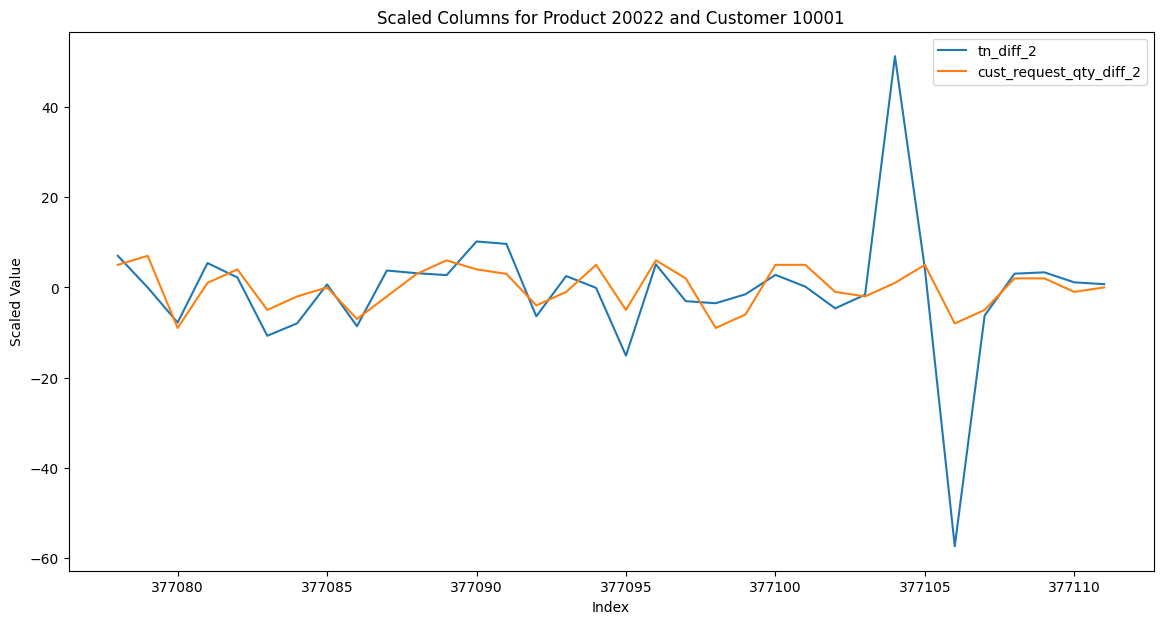

In [12]:
# plot en un mismo grafico tn_scaled y tn_rolling_max_12_scaled para product 20001 y customer 10001
import matplotlib.pyplot as plt
def plot_scaled_columns(df, product_id, customer_id, columns):
    subset = df[(df['product_id'] == product_id) & (df['customer_id'] == customer_id)]
    print(subset[columns].iloc[-1])
    plt.figure(figsize=(14, 7))
    for col in columns:
        plt.plot(subset.index, subset[col], label=col)
    plt.title(f'Scaled Columns for Product {product_id} and Customer {customer_id}')
    plt.xlabel('Index')
    plt.ylabel('Scaled Value')
    plt.legend()
    plt.show()
# Llamar a la función para graficar
plot_scaled_columns(df_scaled, product_id=20022, customer_id=10001, columns=['tn_diff_2', "cust_request_qty_diff_2"])

In [9]:
plot_scaled_columns(df_scaled, product_id=20001, customer_id=10002, columns=['tn_scaled'])

IndexError: single positional indexer is out-of-bounds

In [10]:
# el target es tn 2 meses hacia delante
df_scaled['target'] = df_scaled.groupby(['customer_id', 'product_id'])['tn_scaled'].shift(-2)
#df_scaled['target'] = df_scaled.groupby(['customer_id', 'product_id'])['tn_diff_2_scaled'].shift(-2)
df_scaled["target"].describe()



count    1.128649e+06
mean     3.965255e-02
std      2.757812e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      7.462209e+01
Name: target, dtype: float64

In [ ]:
df_scaled["target"]

In [11]:
real_target = pd.DataFrame(df.groupby(['customer_id', 'product_id'])['tn'].shift(-2))

In [12]:
def predict_test(model, X_test, real_target, test_index):
    X_test = df_scaled.loc[test_index].drop(columns=["target", "fecha"])
    predictions = model.predict(X_test)
    df_result = X_test[['customer_id', 'product_id', "tn_scaled", "tn"]].copy()
    df_result['predictions_scaled'] = predictions

    # Mergeá las stats de tn
    df_result = df_result.merge(
        group_stats[['customer_id', 'product_id', 'tn_diff_2_mean', 'tn_diff_2_std', "tn_std", "tn_mean"]],
        #group_stats[['product_id', 'tn_diff_2_mean', 'tn_diff_2_std', "tn_std", "tn_mean"]],
        #group_stats[['customer_id', 'product_id', 'tn_diff_2_median', 'tn_diff_2_iqr', "tn_iqr", "tn_median"]],
        on=['customer_id', 'product_id'],
        #on=['product_id'],
        how='left'
    )
    df_result.set_index(test_index, inplace=True)
    #df_result['predictions'] = df_result['predictions_scaled'] * df_result['tn_std'] + df_result['tn_mean']
    df_result['predictions'] = df_result['predictions_scaled'] * df_result['tn_std']
    #df_result['predictions'] = df_result['predictions_scaled'] * df_result['tn_std'] + df_result['tn_mean']
    # hago la inversa de la diferencia con tn
    #df_result["predictions"] = df_result['predictions'] + df_result['tn']
    # Invertí el escalado

    # multiplico predictions por predictions_df["predictions_binary"] que es el clasificador de 0s
    #df_result["predictions"] = df_result["predictions"] * predictions_df["predictions_binary"]

    df_result = df_result[['customer_id', 'product_id', 'predictions']]
    df_result["target"] = real_target.loc[test_index, "tn"]
    return df_result


# agrupo por product_id y sumo todos los target y predictions
def calculate_total_error(df_result, alpha=1.0):
    grouped = df_result.groupby('product_id').agg({
        'predictions': 'sum',
        'target': 'sum'
    }).reset_index()
    grouped['predictions'] = grouped['predictions'] * alpha
    grouped['abs_error'] = np.abs(grouped['predictions'] - grouped['target'])
    total_error = grouped['abs_error'].sum() / grouped['target'].sum()
    return grouped, total_error

In [13]:
# count targets that are 0s
print("Porcentaje de targets que son 0s:")
print((df_scaled['target'] == 0).mean() * 100)

Porcentaje de targets que son 0s:
74.90314964378597


In [ ]:
# TODO: primero hago un clasificador para predecir si el target es 0 o no, luego hago un regresor para predecir el valor del target
"""
import lightgbm as lgb
X_train = df_scaled.loc[train_index].drop(columns=["target", "fecha"])
y_train = df_scaled.loc[train_index, "target"]
# transformo y_train a 0s y 1s
y_train_binary = (y_train != 0).astype(int)
cat_features = [col for col in X_train.columns if X_train[col].dtype.name == 'category']
train_data = lgb.Dataset(X_train, label=y_train_binary, categorical_feature=cat_features)
y_test = df_scaled.loc[test_index, "target"]
y_test_binary = (y_test != 0).astype(int)
X_test = df_scaled.loc[test_index].drop(columns=["target", "fecha"])
test_data = lgb.Dataset(X_test, label=y_test_binary, categorical_feature=cat_features)
params = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.9,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': 0
}
model = lgb.train(params, train_data, valid_sets=[train_data, test_data],
                    valid_names=['train', 'test'], num_boost_round=1000)
"""

In [ ]:
"""
predictions_binary = model.predict(X_test)
predictions_binary = (predictions_binary > 0.5).astype(int)
"""

In [ ]:
"""
predictions_df = pd.DataFrame({
    'customer_id': X_test['customer_id'],
    'product_id': X_test['product_id'],
    'predictions_binary': predictions_binary,
    'target': y_test_binary
})
# matriz de confusion en base a predictions_df
# porcentaje de 0s que son 0s
true_zeros = ((predictions_df['predictions_binary'] == 0) & (predictions_df['target'] == 0)).sum()
# Falsos ceros: predijo 0 pero el target NO es 0
false_zeros = ((predictions_df['predictions_binary'] == 0) & (predictions_df['target'] != 0)).sum()
# Porcentaje de 0s verdaderos que no fueron predichos
no_pred_zeros = ((predictions_df['predictions_binary'] != 0) & (predictions_df['target'] == 0)).sum()

print("cantidad de 0s en prediccions que si son 0s:", true_zeros/ len(predictions_df))
print("cantidad de 0s en prediccions que no son 0s:", false_zeros/ len(predictions_df))
print("cantidad de 0s que no fueron predichos:", no_pred_zeros/ len(predictions_df))
"""

In [14]:

import lightgbm as lgb
y_train = df_scaled.loc[train_index, 'target'].dropna()
X_train = df_scaled.loc[y_train.index].drop(columns=["target", "fecha"])
y_test = df_scaled.loc[test_index, 'target']
X_test = df_scaled.loc[test_index].drop(columns=["target", "fecha"])
cat_features = [col for col in X_train.columns if X_train[col].dtype.name == 'category']
train_data = lgb.Dataset(X_train, label=y_train, categorical_feature=cat_features)
#val_data = lgb.Dataset(y_test.loc[y_test.dropna().index], label=y_test.dropna(), reference=train_data)

X_test = df_scaled.loc[test_index].drop(columns=["target", "fecha"])
# creo callback que se ejecuta cad 200 iteraciones y calcula el total_error
def total_error_callback(env):
    if env.iteration % 200 == 0 and env.iteration > 0:
        df_result = predict_test(env.model, X_test, real_target, test_index)
        grouped, total_error = calculate_total_error(df_result)
        print(f"Iteration {env.iteration}, Total Error: {total_error:.4f}")
        print(grouped.sort_values(by='abs_error', ascending=False).head(10))

# create learning_rate scheduler, arranca en 0.1 y cada iteracion baja 0.99 ** iter
def learning_rate_scheduler(iteration):
    min_lr = 0.001
    new_lr = 0.1 * (0.999 ** iteration)
    new_lr = max(new_lr, min_lr)  # Ensure the learning rate does not go below min_lr
    return new_lr


def num_leaves_scheduler(iteration):
    # Reduce the number of leaves as the iterations increase
    return max(17, 512 - iteration )  # Ensure it doesn't go below 31

callbacks = [
    lgb.log_evaluation(period=50),
    total_error_callback, 
    lgb.reset_parameter(learning_rate=learning_rate_scheduler)
]
model = lgb.train(
    params={
        'objective': 'regression',
        'boosting_type': 'gbdt',
        'metric': 'rmse',
        'num_leaves': 52,
        'learning_rate': 0.05,
        'feature_fraction': 0.2,
        'bagging_fraction': 0.8,
        'bagging_freq': 5,
        'verbose': -1,
        #'max_depth': 10,
        "max_bin": 512,
        "verbose": 0
    },
    train_set=train_data,
    num_boost_round=1000,
    callbacks=callbacks,
    valid_sets=[train_data],
    #early_stopping_rounds=50
)

[50]	training's rmse: 0.204388
[100]	training's rmse: 0.196973
[150]	training's rmse: 0.1919
[200]	training's rmse: 0.187884
Iteration 200, Total Error: 0.4168
    product_id  predictions      target   abs_error
0        20012   373.595393  173.130035  200.465358
6        20077   104.948000   34.588470   70.359529
7        20078   118.157053   51.378662   66.778391
8        20079    73.270965   27.684959   45.586005
2        20029   181.799769  150.648697   31.151073
9        20112    81.657352  107.062630   25.405278
13       20175    37.699189   19.285250   18.413940
18       20242    18.043247    4.036040   14.007206
5        20076    81.546186   68.459221   13.086965
4        20073   109.722206  122.470192   12.747986
[250]	training's rmse: 0.184663
[300]	training's rmse: 0.182041
[350]	training's rmse: 0.179576
[400]	training's rmse: 0.177448
Iteration 400, Total Error: 0.4109
    product_id  predictions      target   abs_error
0        20012   371.621527  173.130035  198.491492
6

In [ ]:
X_test["cat1"].dtype

In [15]:
import numpy as np


df_result = predict_test(model, df_scaled, real_target, test_index)
df_result["abs_error"] = np.abs(df_result['predictions'] - df_result['target'])
#df_result["predictions_binary"] = predictions_df["predictions_binary"]
df_result

,customer_id,product_id,predictions,target,abs_error
196515,10001,20012,55.521308,12.75674,42.764569
446583,10001,20026,13.035222,27.29907,14.263848
500169,10001,20029,11.712554,5.48935,6.223204
924448,10001,20054,6.022670,1.12010,4.902570
1259378,10001,20073,26.120228,23.11125,3.008979
...,...,...,...,...,...
14981750,10606,21170,0.000007,0.00000,0.000007
15070494,10606,21182,0.000018,0.00000,0.000018
15358656,10606,21222,0.000010,0.00000,0.000010
15398844,10606,21228,0.000015,NaN,NaN


In [21]:


grouped, total_error = calculate_total_error(df_result, 0.8)
print("Total Error:", total_error)
print(grouped.sort_values(by='abs_error', ascending=False).head(10))

Total Error: 0.35113792184591963
    product_id  predictions      target   abs_error
0        20012   300.484851  173.130035  127.354816
1        20026   185.308663  235.104187   49.795524
6        20077    82.438432   34.588470   47.849961
7        20078    96.081103   51.378662   44.702441
9        20112    67.710302  107.062630   39.352328
4        20073    87.321697  122.470192   35.148495
8        20079    57.209475   27.684959   29.524516
3        20054   100.848809  121.209099   20.360290
17       20213    38.840388   58.840431   20.000044
10       20126    81.625224   94.952881   13.327657


In [14]:
grouped

,product_id,predictions,target,abs_error
0,20012,361.829951,173.130035,188.699916
1,20026,203.203432,235.104187,31.900755
2,20029,184.695452,150.648697,34.046755
3,20054,114.815239,121.209099,6.393860
4,20073,98.246278,122.470192,24.223914
...,...,...,...,...
64,21170,0.393454,0.040780,0.352674
65,21182,0.488352,0.066880,0.421472
66,21222,0.334612,0.021840,0.312772
67,21228,0.114592,0.000000,0.114592


In [64]:
importance_df = pd.DataFrame({
    'feature': model.feature_name(),
    'importance': model.feature_importance()
}).sort_values(by='importance', ascending=False)
print(importance_df.to_string())

                                feature  importance
80              tn_customer_id_vendidas        1294
84                      tn_lag_1_scaled         902
76                 tn_sku_size_vendidas         859
112  tn_customer_id_vendidas_div_scaled         829
74                    tn_brand_vendidas         782
86                      tn_lag_3_scaled         781
72                     tn_cat3_vendidas         752
70                     tn_cat2_vendidas         725
26                             tn_lag_1         724
127     tn_diff_2_rolling_mean_3_scaled         719
78               tn_product_id_vendidas         694
28                             tn_lag_3         675
110   tn_product_id_vendidas_div_scaled         665
88                      tn_lag_6_scaled         661
1                           customer_id         650
40                    tn_rolling_mean_3         647
82                            tn_scaled         646
36                      tn_diff_2_lag_4         643
94          

In [16]:
# las 100 mejores features son:
top_100_features = importance_df.head(100)
print(top_100_features["feature"].to_list())


['customer_id', 'tn_customer_id_vendidas', 'tn_lag_1_scaled', 'tn_diff_1_scaled', 'tn_diff_2_rolling_mean_3_scaled', 'tn_lag_3_scaled', 'tn_sku_size_vendidas', 'tn_scaled', 'tn_lag_1', 'tn_lag_6_scaled', 'tn_brand_vendidas', 'tn_diff_2_lag_6_scaled', 'tn_brand_vendidas_scaled', 'tn_customer_id_vendidas_div_scaled', 'tn_cat3_vendidas', 'tn_rolling_max_12_scaled', 'tn_diff_2_lag_3_scaled', 'tn_product_id_vendidas_div_scaled', 'tn_product_id_vendidas_scaled', 'tn_brand_vendidas_div_scaled', 'tn_diff_2_rolling_max_3_scaled', 'tn_rolling_min_3', 'tn_diff_2_scaled', 'tn_rolling_max_3_scaled', 'tn_rolling_min_3_scaled', 'brand', 'tn_diff_2_rolling_min_12_scaled', 'tn_diff_2_lag_4_scaled', 'tn_diff_2_lag_4', 'tn_lag_6', 'tn_diff_2_lag_2', 'tn_cat1_vendidas', 'tn_cat1_vendidas_scaled', 'tn_cat2_vendidas_scaled', 'tn_cat3_vendidas_scaled', 'tn_product_id_vendidas', 'tn_rolling_mean_3', 'cat3', 'tn_diff_2_rolling_std_3_scaled', 'tn_cat2_vendidas', 'tn_cat1_vendidas_div_scaled', 'tn_customer_id_ve